In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import random
%matplotlib inline
%matplotlib ipympl
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
data = pd.read_csv("data.csv")
events = pd.read_csv("events.csv")

print("DATA columns:")
print(data.columns.tolist())

print("\nEVENTS columns:")
print(events.columns.tolist())

DATA columns:
['order_id', 'user_id', 'status', 'gender', 'created_at', 'returned_at', 'shipped_at', 'delivered_at', 'num_of_item', 'product_id', 'inventory_item_id', 'sale_price', 'id', 'first_name', 'last_name', 'email', 'age', 'state', 'street_address', 'postal_code', 'city', 'country', 'traffic_source', 'user_geom', 'cost', 'category', 'brand', 'retail_price', 'department', 'sku', 'distribution_center_id', 'sold_at', 'product_category', 'product_name', 'product_brand', 'product_retail_price', 'product_department', 'product_sku', 'product_distribution_center_id', 'distribution_center_geom', 'order_item_id', 'delivery_longitude', 'delivery_latitude', 'warehouse_name', 'warehouse_longitude', 'warehouse_latitude', 'is_loyal', 'product_name_clean', 'customer_review']

EVENTS columns:
['id', 'user_id', 'sequence_number', 'session_id', 'created_at', 'ip_address', 'city', 'state', 'postal_code', 'browser', 'traffic_source', 'uri', 'event_type']


0          32.990002
1          39.570000
2         221.979996
3          25.000000
4          25.000000
             ...    
545773     25.000000
545774     29.000000
545775     29.990000
545776     59.189999
545777     22.889999
Name: sale_price, Length: 545778, dtype: float64

In [203]:
import pandas as pd


class SimplePreprocessor:
    def __init__(self):
        self.columns = [
            'user_id',
            'order_id',
            'status',
            'category',
            'brand',
            'age',
            'is_loyal',
            'gender',
            'country',
            'sale_price',
            'created_at'
        ]

        self.valid_status = ['Complete', 'Shipped', 'Processing']

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()

        print(f"Initial rows: {len(df)}")

        # 1. оставить только нужные колонки
        df = df[self.columns]
        print(f"After column selection: {len(df)}")

        # 2. удалить дубликаты
        df = df.drop_duplicates()
        print(f"After drop_duplicates: {len(df)}")

        # 3. удалить строки с NaN
        df = df.dropna()
        print(f"After dropna: {len(df)}")

        # 4. фильтр статусов
        df = df[df['status'].isin(self.valid_status)]
        print(f"After status filter: {len(df)}")

        return df.reset_index(drop=True)

In [110]:
prep = SimplePreprocessor()

df_clean = prep.transform(data)

Initial rows: 545778
After column selection: 545778
After drop_duplicates: 181786
After dropna: 181602
After status filter: 135951


In [111]:

class OrderOneHot:
    def __init__(self, keep_user_features=False):
        self.keep_user_features = keep_user_features
        self.user_cols = ['user_id', 'age', 'is_loyal', 'gender']

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()

        # 1. one-hot матрица (просто наличие категории)
        matrix = (
            df.groupby(['order_id', 'category'])
            .size()                      # считаем количество
            .unstack(fill_value=0)       # pivot
        )

        # бинаризация (0/1)
        matrix = (matrix > 0).astype(int)

        # 2. при необходимости добавляем user info
        if self.keep_user_features:
            user_info = (
                df.groupby('order_id')[self.user_cols]
                .first()
            )

            matrix = matrix.join(user_info)

        print(f"Final matrix shape: {matrix.shape}")

        return matrix

In [112]:
df_clean_M = df_clean[df_clean['gender'] == 'M']
order_sizes = df_clean.groupby('order_id')['category'].nunique()
valid_orders = order_sizes[order_sizes >= 2].index

df_multi = df_clean_M[df_clean_M['order_id'].isin(valid_orders)]

# 2. строим one-hot
# 3. запускаем FP-Growth
oh_encoder = OrderOneHot()
df_oh = oh_encoder.transform(df_multi)

Final matrix shape: (13420, 14)


In [91]:
df_oh.sample()

category,Accessories,Active,Fashion Hoodies & Sweatshirts,Jeans,Outerwear & Coats,Pants,Shorts,Sleep & Lounge,Socks,Suits & Sport Coats,Sweaters,Swim,Tops & Tees,Underwear
order_id,,,,,,,,,,,,,,
103130,1,0,0,0,0,1,0,0,0,0,0,1,1,0


In [75]:
from mlxtend.frequent_patterns import fpgrowth, association_rules


class FPGrowthAnalyzer:
    def __init__(self, min_support=0.01, min_confidence=0.2):
        self.min_support = min_support
        self.min_confidence = min_confidence

    def fit(self, order_matrix: pd.DataFrame):
        df = order_matrix.copy()

        print(f"Initial matrix shape: {df.shape}")

        # 1. бинаризация (есть товар или нет)
        df_binary = (df >= 0.5).astype(int)

        # 2. FP-Growth
        frequent_itemsets = fpgrowth(
            df_binary,
            min_support=self.min_support,
            use_colnames=True
        )

        print(f"Frequent itemsets: {len(frequent_itemsets)}")

        # 3. правила
        rules = association_rules(
            frequent_itemsets,
            metric="confidence",
            min_threshold=self.min_confidence
        )

        print(f"Rules found: {len(rules)}")

        return frequent_itemsets, rules

In [76]:
fp = FPGrowthAnalyzer(min_support=0.003, min_confidence=0.01)

itemsets, rules = fp.fit(df_oh)

Initial matrix shape: (13420, 14)


/home/artem/.local/lib/python3.10/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Frequent itemsets: 109
Rules found: 206


In [77]:
rules.to_csv("rules.csv", index=False)

In [78]:
rules['lift'].describe()

count    206.000000
mean       0.706476
std        0.049501
min        0.535067
25%        0.684738
50%        0.710043
75%        0.737634
max        0.815381
Name: lift, dtype: float64

In [79]:
order_sizes = df_clean.groupby('order_id')['category'].nunique()

print(order_sizes.value_counts(normalize=True))

category
1    0.712418
2    0.197706
3    0.057151
4    0.032725
Name: proportion, dtype: float64


In [80]:
from scipy.stats import ttest_1samp

ttest_1samp(rules['lift'], 1)

TtestResult(statistic=-85.10589871846408, pvalue=6.639813180583598e-162, df=205)

In [204]:
prep = SimplePreprocessor()
df_clean = prep.transform(data)
oh_encoder = OrderOneHot(keep_user_features=True)
df = oh_encoder.transform(df_clean)

Initial rows: 545778
After column selection: 545778
After drop_duplicates: 181916
After dropna: 181732
After status filter: 136054
Final matrix shape: (93629, 30)


In [205]:
df

,Accessories,Active,Blazers & Jackets,Clothing Sets,Dresses,Fashion Hoodies & Sweatshirts,Intimates,Jeans,Jumpsuits & Rompers,Leggings,...,Suits,Suits & Sport Coats,Sweaters,Swim,Tops & Tees,Underwear,user_id,age,is_loyal,gender
order_id,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,40,False,M
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,2,46,True,F
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,4,26,False,F
7,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,7,70,False,M
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,8,27,True,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125080,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,99995,60,True,F
125081,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,99996,66,True,F
125082,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,99996,66,True,F


In [206]:
import pandas as pd

# =========================================================
# 1. PREPROCESS (ROBUST)
# =========================================================
df = df_clean.copy()

if 'returned_at' in df.columns:
    df = df[df['returned_at'].isna()]

if 'status' in df.columns:
    valid_status = ['Complete', 'Shipped', 'Processing']
    df = df[df['status'].isin(valid_status)]

# =========================================================
# 2. AGE GROUPS
# =========================================================
def age_to_group(age):
    if pd.isna(age):
        return 'unknown'
    if age < 18: return '0-17'
    if age < 25: return '18-24'
    if age < 35: return '25-34'
    if age < 50: return '35-49'
    return '50+'

df['age_group'] = df['age'].apply(age_to_group)

# =========================================================
# 3. DETECT ITEM COLUMN
# =========================================================
possible_item_cols = [
    'product_id',
    'product_name_clean',
    'product_name',
    'category'
]

ITEM_COL = None
for col in possible_item_cols:
    if col in df.columns:
        ITEM_COL = col
        break

if ITEM_COL is None:
    raise ValueError(f"No item column found. Available columns: {list(df.columns)}")

print(f"Using ITEM_COL = {ITEM_COL}")

# =========================================================
# 4. USER-ITEM BINARY
# =========================================================
user_item = (
    df.groupby(['user_id', ITEM_COL])
    .size()
    .reset_index(name='cnt')
)

user_item['bought'] = 1

# =========================================================
# 5. USER INFO
# =========================================================
required_cols = ['user_id', 'gender', 'is_loyal', 'age_group']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

user_info = df[required_cols].drop_duplicates()

# =========================================================
# 6. MERGE
# =========================================================
user_item = user_item.merge(user_info, on='user_id', how='left')

# =========================================================
# 7. SEGMENT SIZE
# =========================================================
segment_size = (
    user_info
    .groupby(['gender', 'is_loyal', 'age_group'])['user_id']
    .nunique()
    .reset_index(name='n_users')
)

# =========================================================
# 8. USERS WHO BOUGHT ITEM
# =========================================================
segment_item = (
    user_item
    .groupby(['gender', 'is_loyal', 'age_group', ITEM_COL])['user_id']
    .nunique()
    .reset_index(name='n_buyers')
)

# =========================================================
# 9. PROBABILITY
# =========================================================
segment_item = segment_item.merge(
    segment_size,
    on=['gender', 'is_loyal', 'age_group'],
    how='left'
)

segment_item['prob'] = segment_item['n_buyers'] / segment_item['n_users']

# =========================================================
# 10. TOP-10
# =========================================================
top10 = (
    segment_item
    .sort_values(['gender', 'is_loyal', 'age_group', 'prob'], ascending=[True, True, True, False])
    .groupby(['gender', 'is_loyal', 'age_group'])
    .head(10)
    .reset_index(drop=True)
)

# =========================================================
# 11. SAVE
# =========================================================
top10.to_csv("top10_items_per_segment.csv", index=False)

# =========================================================
# 12. VIEW
# =========================================================
print(top10.head(20))

Using ITEM_COL = category
   gender  is_loyal age_group                       category  n_buyers  \
0       F     False      0-17                      Intimates       543   
1       F     False      0-17                           Swim       235   
2       F     False      0-17                          Jeans       213   
3       F     False      0-17                         Shorts       211   
4       F     False      0-17  Fashion Hoodies & Sweatshirts       210   
5       F     False      0-17                 Sleep & Lounge       210   
6       F     False      0-17                        Dresses       208   
7       F     False      0-17                    Tops & Tees       204   
8       F     False      0-17                           Plus       197   
9       F     False      0-17                      Maternity       196   
10      F     False     18-24                      Intimates       586   
11      F     False     18-24                        Dresses       293   
12      F   

/tmp/ipykernel_7411/512430967.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(all_items))
/home/artem/.local/lib/python3.10/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


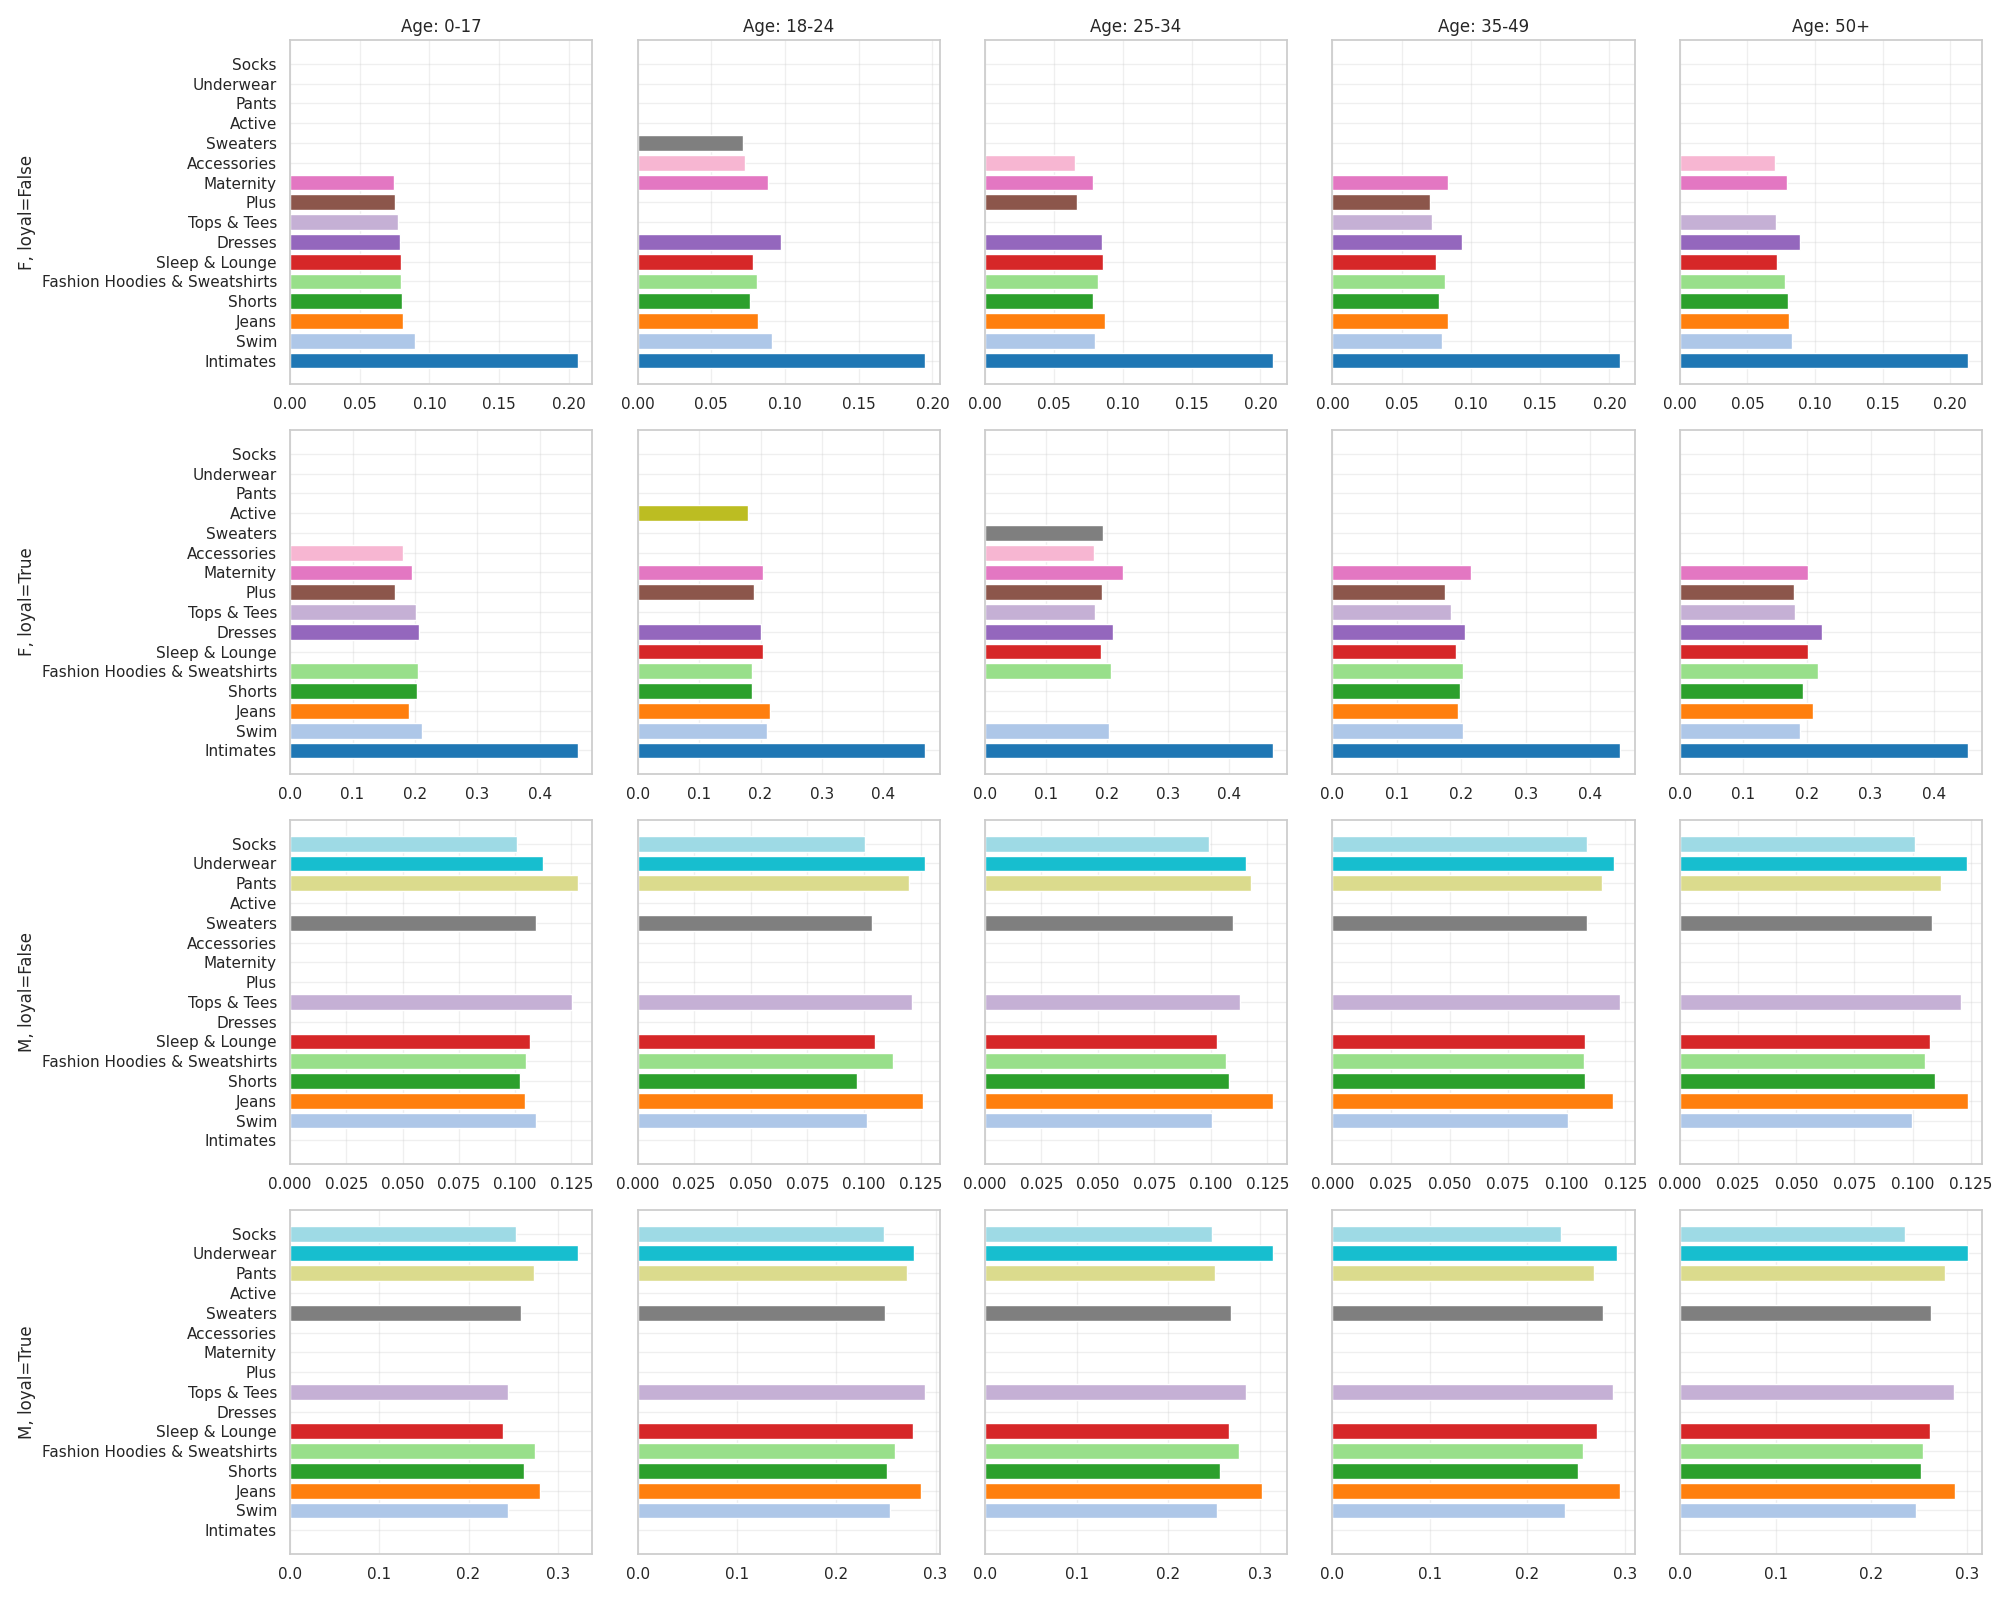

In [207]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. LOAD
# =========================================================
top10 = pd.read_csv("top10_items_per_segment.csv")

# определяем колонку товара
ITEM_COL = None
for col in ['product_id', 'product_name_clean', 'product_name', 'category']:
    if col in top10.columns:
        ITEM_COL = col
        break

if ITEM_COL is None:
    raise ValueError("Item column not found")

# =========================================================
# 2. УНИКАЛЬНЫЕ ЗНАЧЕНИЯ
# =========================================================
age_groups = sorted(top10['age_group'].unique())
genders = sorted(top10['gender'].unique())
loyals = sorted(top10['is_loyal'].unique())

# создаем все комбинации (gender × loyal)
segments = [(g, l) for g in genders for l in loyals]

# =========================================================
# 3. ЦВЕТА ДЛЯ ТОВАРОВ
# =========================================================
all_items = top10[ITEM_COL].unique()
color_map = {item: i for i, item in enumerate(all_items)}

# используем colormap
cmap = plt.cm.get_cmap('tab20', len(all_items))

# =========================================================
# 4. PLOT
# =========================================================
n_rows = len(segments)
n_cols = len(age_groups)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows), sharey=True)

if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for i, (gender, is_loyal) in enumerate(segments):
    for j, age_group in enumerate(age_groups):

        ax = axes[i, j]

        df_plot = top10[
            (top10['gender'] == gender) &
            (top10['is_loyal'] == is_loyal) &
            (top10['age_group'] == age_group)
        ]

        if df_plot.empty:
            ax.set_title(f"{age_group}\n(empty)")
            continue

        items = df_plot[ITEM_COL].astype(str).values
        probs = df_plot['prob'].values

        colors = [cmap(color_map[item]) for item in items]

        ax.barh(items, probs, color=colors)

        if i == 0:
            ax.set_title(f"Age: {age_group}")

        if j == 0:
            ax.set_ylabel(f"{gender}, loyal={is_loyal}")

        ax.invert_yaxis()
        ax.grid(alpha=0.3)

# =========================================================
# 5. FINAL TOUCH
# =========================================================
plt.tight_layout()
plt.show()

In [208]:
import pandas as pd
from scipy.stats import chi2_contingency

# =========================================================
# 1. PREPROCESS
# =========================================================
df = df_clean.copy()

if 'returned_at' in df.columns:
    df = df[df['returned_at'].isna()]

if 'status' in df.columns:
    df = df[df['status'].isin(['Complete', 'Shipped', 'Processing'])]

# =========================================================
# 2. AGE GROUPS
# =========================================================
def age_to_group(age):
    if pd.isna(age):
        return 'unknown'
    if age < 18: return '0-17'
    if age < 25: return '18-24'
    if age < 35: return '25-34'
    if age < 50: return '35-49'
    return '50+'

df['age_group'] = df['age'].apply(age_to_group)

# =========================================================
# 3. CATEGORY COLUMN
# =========================================================
if 'category' not in df.columns:
    raise ValueError("Нет category — тест невозможен")

# =========================================================
# 4. CONTINGENCY TABLE
# =========================================================
# строки — возраст, колонки — категории
contingency = pd.crosstab(df['age_group'], df['category'])

# =========================================================
# 5. CHI-SQUARE TEST
# =========================================================
chi2, p_value, dof, expected = chi2_contingency(contingency)

print("Chi2:", chi2)
print("p-value:", p_value)
print("dof:", dof)

# =========================================================
# 6. INTERPRETATION
# =========================================================
alpha = 0.05

if p_value < alpha:
    print("\n❌ ОТВЕРГАЕМ H0: покупки ЗАВИСЯТ от возраста")
else:
    print("\n✅ НЕ ОТВЕРГАЕМ H0: зависимости НЕ обнаружено")

# =========================================================
# 7. EFFECT SIZE (Cramer's V)
# =========================================================
import numpy as np

n = contingency.values.sum()
r, k = contingency.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("\nCramer's V:", cramers_v)

Chi2: 91.44516364506937
p-value: 0.7175491971656156
dof: 100

✅ НЕ ОТВЕРГАЕМ H0: зависимости НЕ обнаружено

Cramer's V: 0.01296267754339138


In [209]:
import pandas as pd

# =========================================================
# 1. PREPROCESS (ROBUST)
# =========================================================
df = df_clean.copy()

if 'returned_at' in df.columns:
    df = df[df['returned_at'].isna()]

if 'status' in df.columns:
    valid_status = ['Complete', 'Shipped', 'Processing']
    df = df[df['status'].isin(valid_status)]

# =========================================================
# 2. DETECT ITEM COLUMN
# =========================================================
possible_item_cols = [
    'product_id',
    'product_name_clean',
    'product_name',
    'category'
]

ITEM_COL = None
for col in possible_item_cols:
    if col in df.columns:
        ITEM_COL = col
        break

if ITEM_COL is None:
    raise ValueError(f"No item column found. Available columns: {list(df.columns)}")

print(f"Using ITEM_COL = {ITEM_COL}")

# =========================================================
# 3. USER-ITEM BINARY
# =========================================================
user_item = (
    df.groupby(['user_id', ITEM_COL])
    .size()
    .reset_index(name='cnt')
)

user_item['bought'] = 1

# =========================================================
# 4. USER INFO (без возраста)
# =========================================================
required_cols = ['user_id', 'gender', 'is_loyal']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

user_info = df[required_cols].drop_duplicates()

# =========================================================
# 5. MERGE
# =========================================================
user_item = user_item.merge(user_info, on='user_id', how='left')

# =========================================================
# 6. SEGMENT SIZE
# =========================================================
segment_size = (
    user_info
    .groupby(['gender', 'is_loyal'])['user_id']
    .nunique()
    .reset_index(name='n_users')
)

# =========================================================
# 7. USERS WHO BOUGHT ITEM
# =========================================================
segment_item = (
    user_item
    .groupby(['gender', 'is_loyal', ITEM_COL])['user_id']
    .nunique()
    .reset_index(name='n_buyers')
)

# =========================================================
# 8. PROBABILITY
# =========================================================
segment_item = segment_item.merge(
    segment_size,
    on=['gender', 'is_loyal'],
    how='left'
)

segment_item['prob'] = segment_item['n_buyers'] / segment_item['n_users']

# =========================================================
# 9. TOP-10
# =========================================================
top10 = (
    segment_item
    .sort_values(['gender', 'is_loyal', 'prob'], ascending=[True, True, False])
    .groupby(['gender', 'is_loyal'])
    .head(10)
    .reset_index(drop=True)
)

# =========================================================
# 10. SAVE
# =========================================================
top10.to_csv("top10_items_per_segment_no_age.csv", index=False)

# =========================================================
# 11. VIEW
# =========================================================
print(top10.head(20))

Using ITEM_COL = category
   gender  is_loyal                       category  n_buyers  n_users  \
0       F     False                      Intimates      5362    25754   
1       F     False                        Dresses      2304    25754   
2       F     False                           Swim      2145    25754   
3       F     False                          Jeans      2131    25754   
4       F     False                      Maternity      2085    25754   
5       F     False  Fashion Hoodies & Sweatshirts      2062    25754   
6       F     False                         Shorts      2022    25754   
7       F     False                 Sleep & Lounge      1969    25754   
8       F     False                    Tops & Tees      1812    25754   
9       F     False                           Plus      1779    25754   
10      F      True                      Intimates      3295     7214   
11      F      True                        Dresses      1531     7214   
12      F      True      

/tmp/ipykernel_7411/1887526246.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(all_items))
/home/artem/.local/lib/python3.10/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


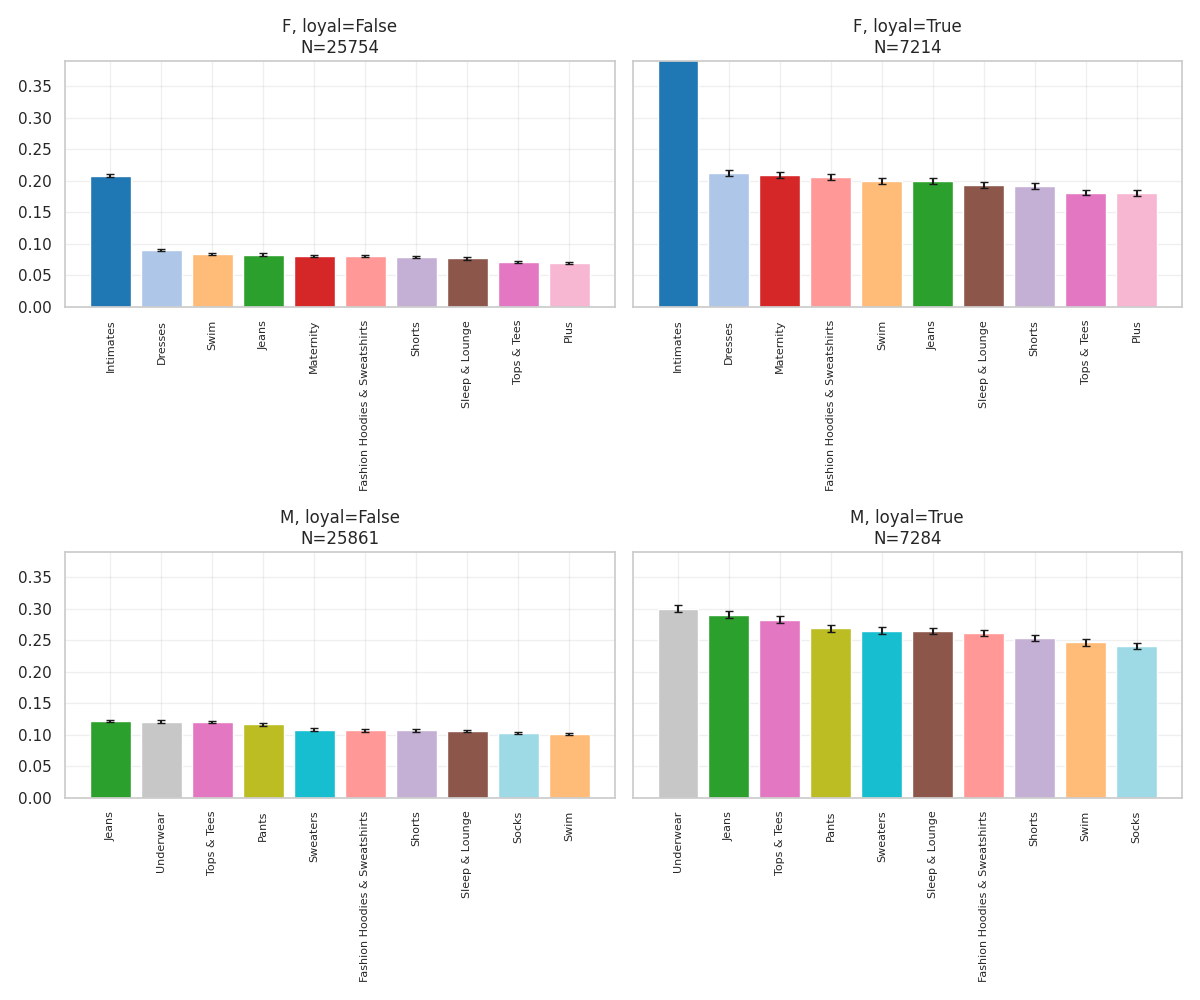

In [210]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. LOAD
# =========================================================
top10 = pd.read_csv("top10_items_per_segment_no_age.csv")

# определяем колонку товара
ITEM_COL = None
for col in ['product_id', 'product_name_clean', 'product_name', 'category']:
    if col in top10.columns:
        ITEM_COL = col
        break

if ITEM_COL is None:
    raise ValueError("Item column not found")

# =========================================================
# 2. SEGMENTS
# =========================================================
genders = sorted(top10['gender'].unique())
loyals = sorted(top10['is_loyal'].unique())

segments = [(g, l) for g in genders for l in loyals]

# =========================================================
# 3. COLOR MAP
# =========================================================
all_items = top10[ITEM_COL].astype(str).unique()
color_map = {item: i for i, item in enumerate(all_items)}
cmap = plt.cm.get_cmap('tab20', len(all_items))

# =========================================================
# 4. PLOT
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)
axes = axes.flatten()

for idx, (gender, is_loyal) in enumerate(segments):

    ax = axes[idx]

    df_plot = top10[
        (top10['gender'] == gender) &
        (top10['is_loyal'] == is_loyal)
    ]

    if df_plot.empty:
        ax.set_title(f"{gender}, loyal={is_loyal}\n(empty)")
        continue

    # сортируем
    df_plot = df_plot.sort_values('prob', ascending=False)

    items = df_plot[ITEM_COL].astype(str).values
    probs = df_plot['prob'].values
    n_users = int(df_plot['n_users'].iloc[0])

    # =====================================================
    # ERROR BARS
    # =====================================================
    errors = np.sqrt(probs * (1 - probs) / n_users)

    colors = [cmap(color_map[item]) for item in items]
    x = np.arange(len(items))

    ax.bar(
        x,
        probs,
        yerr=errors,
        capsize=3,
        color=colors
    )

    ax.set_xticks(x)
    ax.set_xticklabels(items, rotation=90, fontsize=8)

    ax.set_title(f"{gender}, loyal={is_loyal}\nN={n_users}")
    ax.set_ylim(0, max(probs) * 1.3)
    ax.grid(alpha=0.3)

# =========================================================
# 5. FINAL
# =========================================================
plt.tight_layout()
plt.show()

In [211]:
import pandas as pd
import numpy as np
from scipy.stats import entropy, pearsonr, chisquare

# =========================================================
# 1. LOAD
# =========================================================
df = pd.read_csv("top10_items_per_segment_no_age.csv")

ITEM_COL = None
for col in ['product_id', 'product_name_clean', 'product_name', 'category']:
    if col in df.columns:
        ITEM_COL = col
        break

# =========================================================
# 2. СРАВНЕНИЕ LOYAL VS NON-LOYAL
# =========================================================
results = []

for gender in df['gender'].unique():

    df_g = df[df['gender'] == gender]

    df_loyal = df_g[df_g['is_loyal'] == 1]
    df_not = df_g[df_g['is_loyal'] == 0]

    # объединяем по товарам
    merged = pd.merge(
        df_loyal[[ITEM_COL, 'prob']],
        df_not[[ITEM_COL, 'prob']],
        on=ITEM_COL,
        how='outer',
        suffixes=('_loyal', '_not')
    ).fillna(0)

    p_loyal = merged['prob_loyal'].values
    p_not = merged['prob_not'].values

    # =====================================================
    # 1. НОРМАЛИЗАЦИЯ (убираем масштаб)
    # =====================================================
    p_loyal_norm = p_loyal / (p_loyal.sum() + 1e-9)
    p_not_norm = p_not / (p_not.sum() + 1e-9)

    # =====================================================
    # 2. КОРРЕЛЯЦИЯ
    # =====================================================
    corr, _ = pearsonr(p_loyal_norm, p_not_norm)

    # =====================================================
    # 3. KL-DIVERGENCE
    # =====================================================
    kl = entropy(p_loyal_norm + 1e-9, p_not_norm + 1e-9)

    # =====================================================
    # 4. CHI-SQUARE
    # =====================================================
    chi2, p_val = chisquare(p_loyal_norm, p_not_norm)

    results.append({
        'gender': gender,
        'correlation': corr,
        'kl_divergence': kl,
        'chi2_pvalue': p_val
    })

# =========================================================
# 3. RESULT
# =========================================================
res_df = pd.DataFrame(results)
print(res_df)

  gender  correlation  kl_divergence  chi2_pvalue
0      F     0.998011       0.001867          1.0
1      M     0.930875       0.000308          1.0


In [212]:
import pandas as pd

# =========================================================
# 1. PREPROCESS
# =========================================================
df = df_clean.copy()

if 'returned_at' in df.columns:
    df = df[df['returned_at'].isna()]

if 'status' in df.columns:
    df = df[df['status'].isin(['Complete', 'Shipped', 'Processing'])]

# =========================================================
# 2. USER ACTIVITY (товары)
# =========================================================
user_items = (
    df.groupby('user_id')
    .size()
    .reset_index(name='n_items')
)

# =========================================================
# 3. USER ACTIVITY (заказы)
# =========================================================
user_orders = (
    df.groupby('user_id')['order_id']
    .nunique()
    .reset_index(name='n_orders')
)

# =========================================================
# 4. USER INFO
# =========================================================
user_info = df[['user_id', 'gender', 'is_loyal']].drop_duplicates()

# объединяем всё
user_stats = user_items.merge(user_orders, on='user_id')
user_stats = user_stats.merge(user_info, on='user_id')

# =========================================================
# 5. СЧИТАЕМ КОЭФФИЦИЕНТЫ ПО ГЕНДЕРУ
# =========================================================
results = []

for gender in user_stats['gender'].unique():

    df_g = user_stats[user_stats['gender'] == gender]

    loyal = df_g[df_g['is_loyal'] == 1]
    not_loyal = df_g[df_g['is_loyal'] == 0]

    # средние
    items_loyal = loyal['n_items'].mean()
    items_not = not_loyal['n_items'].mean()

    orders_loyal = loyal['n_orders'].mean()
    orders_not = not_loyal['n_orders'].mean()

    # коэффициенты
    k_items = items_loyal / items_not
    k_orders = orders_loyal / orders_not

    results.append({
        'gender': gender,
        'items_loyal': items_loyal,
        'items_not': items_not,
        'k_items': k_items,
        'orders_loyal': orders_loyal,
        'orders_not': orders_not,
        'k_orders': k_orders
    })

# =========================================================
# 6. RESULT
# =========================================================
res_df = pd.DataFrame(results)
print(res_df)

  gender  items_loyal  items_not   k_items  orders_loyal  orders_not  k_orders
0      M     4.009610   1.506438  2.661649      2.153762    1.206875  1.784577
1      F     4.040338   1.504349  2.685772      2.167036    1.207463  1.794702


In [213]:
import pandas as pd

# =========================================================
# 1. PREPROCESS
# =========================================================
df = df_clean.copy()

if 'returned_at' in df.columns:
    df = df[df['returned_at'].isna()]

if 'status' in df.columns:
    df = df[df['status'].isin(['Complete', 'Shipped', 'Processing'])]

# =========================================================
# 2. ITEM COLUMN
# =========================================================
possible_item_cols = [
    'product_id',
    'product_name_clean',
    'product_name',
    'category'
]

ITEM_COL = next((c for c in possible_item_cols if c in df.columns), None)
if ITEM_COL is None:
    raise ValueError("No item column found")

# =========================================================
# 3. USER-ITEM BINARY
# =========================================================
user_item = (
    df.groupby(['user_id', ITEM_COL])
    .size()
    .reset_index(name='cnt')
)

# =========================================================
# 4. USER INFO (gender + country)
# =========================================================
required_cols = ['user_id', 'gender', 'country']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

user_info = df[required_cols].drop_duplicates()

# =========================================================
# 5. MERGE
# =========================================================
user_item = user_item.merge(user_info, on='user_id', how='left')

# =========================================================
# 6. SEGMENT SIZE
# =========================================================
segment_size = (
    user_info
    .groupby(['gender', 'country'])['user_id']
    .nunique()
    .reset_index(name='n_users')
)

# =========================================================
# 7. USERS WHO BOUGHT ITEM
# =========================================================
segment_item = (
    user_item
    .groupby(['gender', 'country', ITEM_COL])['user_id']
    .nunique()
    .reset_index(name='n_buyers')
)

# =========================================================
# 8. PROBABILITY
# =========================================================
segment_item = segment_item.merge(segment_size, on=['gender', 'country'])

segment_item['prob'] = segment_item['n_buyers'] / segment_item['n_users']

# =========================================================
# 9. TOP-10
# =========================================================
top10 = (
    segment_item
    .sort_values(['gender', 'country', 'prob'], ascending=[True, True, False])
    .groupby(['gender', 'country'])
    .head(10)
    .reset_index(drop=True)
)

top10.to_csv("top10_items_gender_country.csv", index=False)
print(top10.head())

  gender    country        category  n_buyers  n_users      prob
0      F  Australia       Intimates       208      778  0.267352
1      F  Australia     Tops & Tees        93      778  0.119537
2      F  Australia       Maternity        90      778  0.115681
3      F  Australia         Dresses        88      778  0.113111
4      F  Australia  Sleep & Lounge        88      778  0.113111


/tmp/ipykernel_7411/4059352549.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(all_items))
/home/artem/.local/lib/python3.10/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


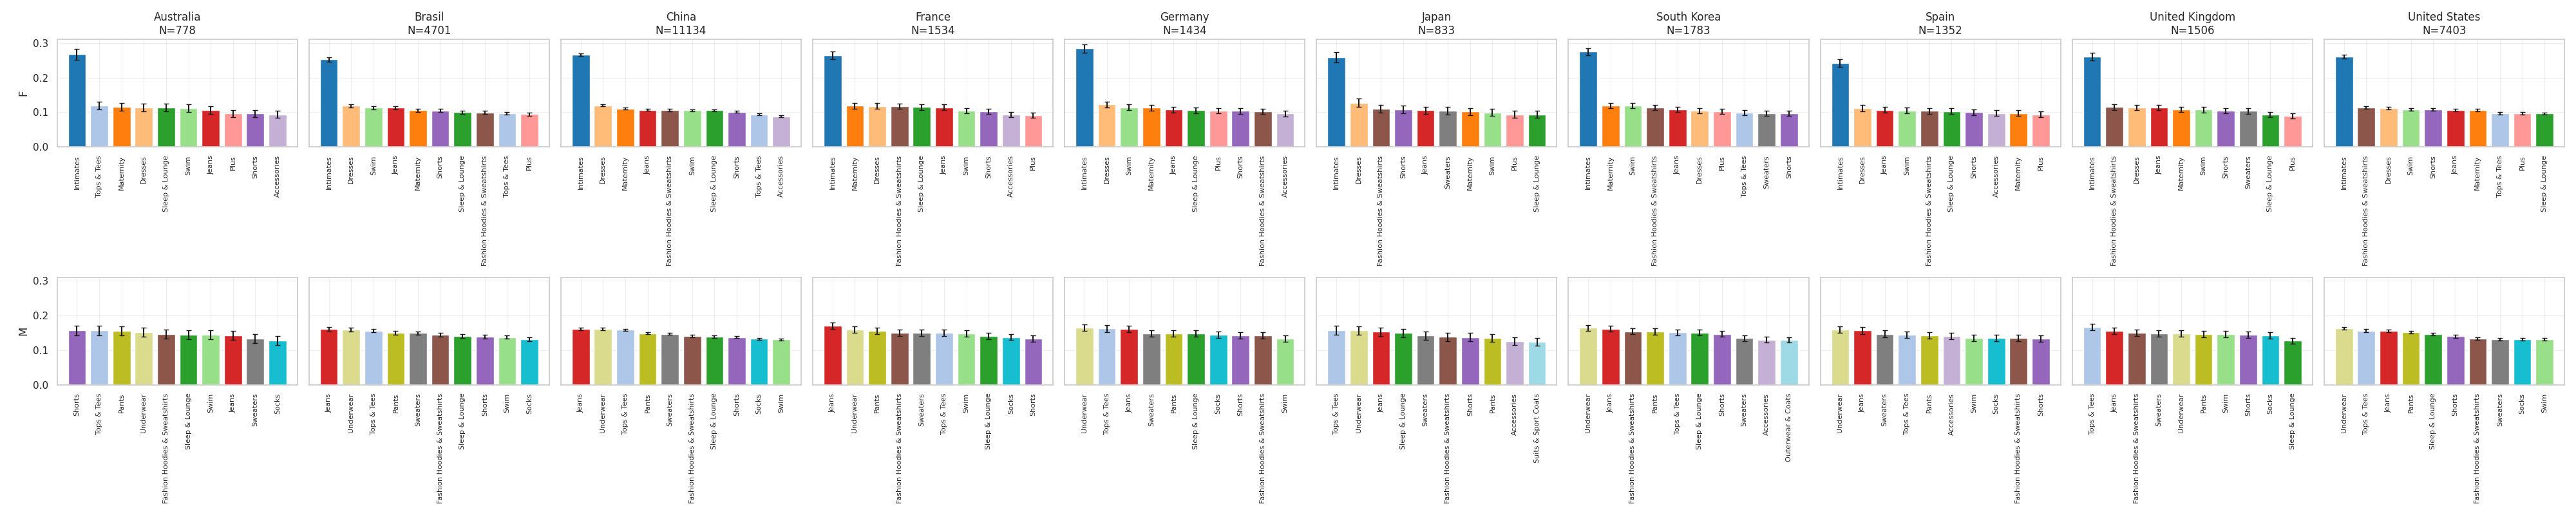

In [214]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. LOAD
# =========================================================
top10 = pd.read_csv("top10_items_gender_country.csv")

ITEM_COL = next(c for c in ['product_id','product_name_clean','product_name','category'] if c in top10.columns)

# =========================================================
# 2. SEGMENTS
# =========================================================
genders = sorted(top10['gender'].unique())
countries = sorted(top10['country'].unique())

# ограничим страны (иначе будет каша)
TOP_COUNTRIES = top10.groupby('country')['n_users'].first().sort_values(ascending=False).head(10).index
countries = [c for c in countries if c in TOP_COUNTRIES]

# =========================================================
# 3. COLOR MAP
# =========================================================
all_items = top10[ITEM_COL].astype(str).unique()
color_map = {item: i for i, item in enumerate(all_items)}
cmap = plt.cm.get_cmap('tab20', len(all_items))

# =========================================================
# 4. PLOT
# =========================================================
fig, axes = plt.subplots(len(genders), len(countries),
                         figsize=(4*len(countries), 4*len(genders)),
                         sharey=True)

if len(genders) == 1:
    axes = np.expand_dims(axes, axis=0)

for i, gender in enumerate(genders):
    for j, country in enumerate(countries):

        ax = axes[i, j]

        df_plot = top10[
            (top10['gender'] == gender) &
            (top10['country'] == country)
        ]

        if df_plot.empty:
            ax.set_title(f"{country}\n(empty)")
            continue

        df_plot = df_plot.sort_values('prob', ascending=False)

        items = df_plot[ITEM_COL].astype(str).values
        probs = df_plot['prob'].values
        n_users = int(df_plot['n_users'].iloc[0])

        # error bars
        errors = np.sqrt(probs * (1 - probs) / n_users)

        colors = [cmap(color_map[item]) for item in items]
        x = np.arange(len(items))

        ax.bar(x, probs, yerr=errors, capsize=3, color=colors)

        ax.set_xticks(x)
        ax.set_xticklabels(items, rotation=90, fontsize=8)

        if i == 0:
            ax.set_title(f"{country}\nN={n_users}")

        if j == 0:
            ax.set_ylabel(gender)

        ax.grid(alpha=0.3)

# =========================================================
# 5. FINAL
# =========================================================
plt.tight_layout()
plt.show()

In [215]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# =========================================================
# 1. PREPROCESS
# =========================================================
df = df_clean.copy()

if 'returned_at' in df.columns:
    df = df[df['returned_at'].isna()]

if 'status' in df.columns:
    df = df[df['status'].isin(['Complete', 'Shipped', 'Processing'])]

# =========================================================
# 2. CHECK COLUMN
# =========================================================
if 'country' not in df.columns:
    raise ValueError("Нет country — тест невозможен")

# =========================================================
# 3. ITEM COLUMN
# =========================================================
possible_item_cols = [
    'product_id',
    'product_name_clean',
    'product_name',
    'category'
]

ITEM_COL = next((c for c in possible_item_cols if c in df.columns), None)
if ITEM_COL is None:
    raise ValueError("Нет колонки товара")

# =========================================================
# 4. УБИРАЕМ РЕДКИЕ СТРАНЫ (очень важно)
# =========================================================
country_counts = df['country'].value_counts()

valid_countries = country_counts[country_counts > 100].index
df = df[df['country'].isin(valid_countries)]

# =========================================================
# 5. CONTINGENCY TABLE
# =========================================================
contingency = pd.crosstab(df['country'], df[ITEM_COL])

# =========================================================
# 6. CHI-SQUARE TEST
# =========================================================
chi2, p_value, dof, expected = chi2_contingency(contingency)

print("Chi2:", chi2)
print("p-value:", p_value)
print("dof:", dof)

# =========================================================
# 7. EFFECT SIZE (Cramer's V)
# =========================================================
n = contingency.values.sum()
r, k = contingency.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("Cramer's V:", cramers_v)

# =========================================================
# 8. INTERPRETATION
# =========================================================
alpha = 0.05

if p_value < alpha:
    print("\n❌ ОТВЕРГАЕМ H0: есть зависимость от страны")
else:
    print("\n✅ НЕ ОТВЕРГАЕМ H0: зависимости нет")

# =========================================================
# 9. ДОПОЛНИТЕЛЬНО: РАЗМЕРЫ СТРАН
# =========================================================
print("\nTop countries by users:")
print(country_counts.head(10))

Chi2: 235.82129381083976
p-value: 0.9580472759391647
dof: 275
Cramer's V: 0.01255364478578415

✅ НЕ ОТВЕРГАЕМ H0: зависимости нет

Top countries by users:
country
China             45697
United States     30350
Brasil            19596
South Korea        7479
France             6561
United Kingdom     6250
Germany            6024
Spain              5461
Japan              3346
Australia          3136
Name: count, dtype: int64


In [216]:
import pandas as pd

# =========================================================
# 1. PREPROCESS
# =========================================================
df = df_clean.copy()

# оставляем только реальные покупки
if 'returned_at' in df.columns:
    df = df[df['returned_at'].isna()]

if 'status' in df.columns:
    df = df[df['status'].isin(['Complete', 'Shipped', 'Processing'])]

# =========================================================
# 2. CHECK PRICE COLUMN
# =========================================================
# выбираем цену
if 'sale_price' in df.columns:
    PRICE_COL = 'sale_price'
elif 'retail_price' in df.columns:
    PRICE_COL = 'retail_price'
else:
    raise ValueError("Нет колонки цены")

# =========================================================
# 3. USER-LEVEL METRICS
# =========================================================
user_stats = (
    df.groupby('user_id')
    .agg(
        total_spent=(PRICE_COL, 'sum'),
        avg_item_price=(PRICE_COL, 'mean'),
        n_items=(PRICE_COL, 'count'),
        n_orders=('order_id', 'nunique')
    )
    .reset_index()
)

# =========================================================
# 4. DERIVED METRICS
# =========================================================
user_stats['avg_order_value'] = user_stats['total_spent'] / user_stats['n_orders']

# =========================================================
# 5. ADD USER INFO
# =========================================================
user_info_cols = ['user_id', 'gender', 'is_loyal', 'country']
available_cols = [c for c in user_info_cols if c in df.columns]

user_info = df[available_cols].drop_duplicates()

user_stats = user_stats.merge(user_info, on='user_id', how='left')

# =========================================================
# 6. SAVE + VIEW
# =========================================================
user_stats.to_csv("user_money_stats.csv", index=False)

print(user_stats.head(20))

    user_id  total_spent  avg_item_price  n_items  n_orders  avg_order_value  \
0         1    55.490002       55.490002        1         1        55.490002   
1         2   124.000000       62.000000        2         1       124.000000   
2         4    22.500000       22.500000        1         1        22.500000   
3         7     7.950000        7.950000        1         1         7.950000   
4         8    42.000000       42.000000        1         1        42.000000   
5        10   332.990002       83.247500        4         1       332.990002   
6        11    62.560000       31.280000        2         1        62.560000   
7        12    13.750000       13.750000        1         1        13.750000   
8        13    38.000000       38.000000        1         1        38.000000   
9        14   979.980000      244.995000        4         2       489.990000   
10       16    67.989998       67.989998        1         1        67.989998   
11       17    84.949997       84.949997

/home/artem/.local/lib/python3.10/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


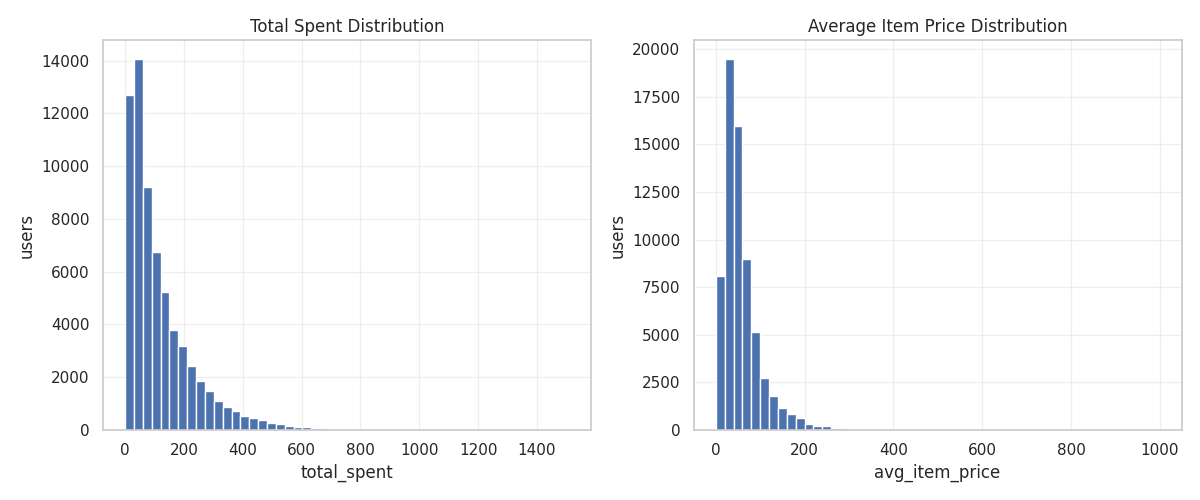

In [217]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. LOAD
# =========================================================
df = pd.read_csv("user_money_stats.csv")

# =========================================================
# 2. REMOVE ZERO / NAN
# =========================================================
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['total_spent', 'avg_item_price'])

df = df[df['total_spent'] > 0]
df = df[df['avg_item_price'] > 0]

# =========================================================
# 3. PLOT
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -------------------------
# total_spent
# -------------------------
axes[0].hist(df['total_spent'], bins=50)
axes[0].set_title("Total Spent Distribution")
axes[0].set_xlabel("total_spent")
axes[0].set_ylabel("users")
axes[0].grid(alpha=0.3)

# -------------------------
# avg_item_price
# -------------------------
axes[1].hist(df['avg_item_price'], bins=50)
axes[1].set_title("Average Item Price Distribution")
axes[1].set_xlabel("avg_item_price")
axes[1].set_ylabel("users")
axes[1].grid(alpha=0.3)

# =========================================================
# 4. FINAL
# =========================================================
plt.tight_layout()
plt.show()

/home/artem/.local/lib/python3.10/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


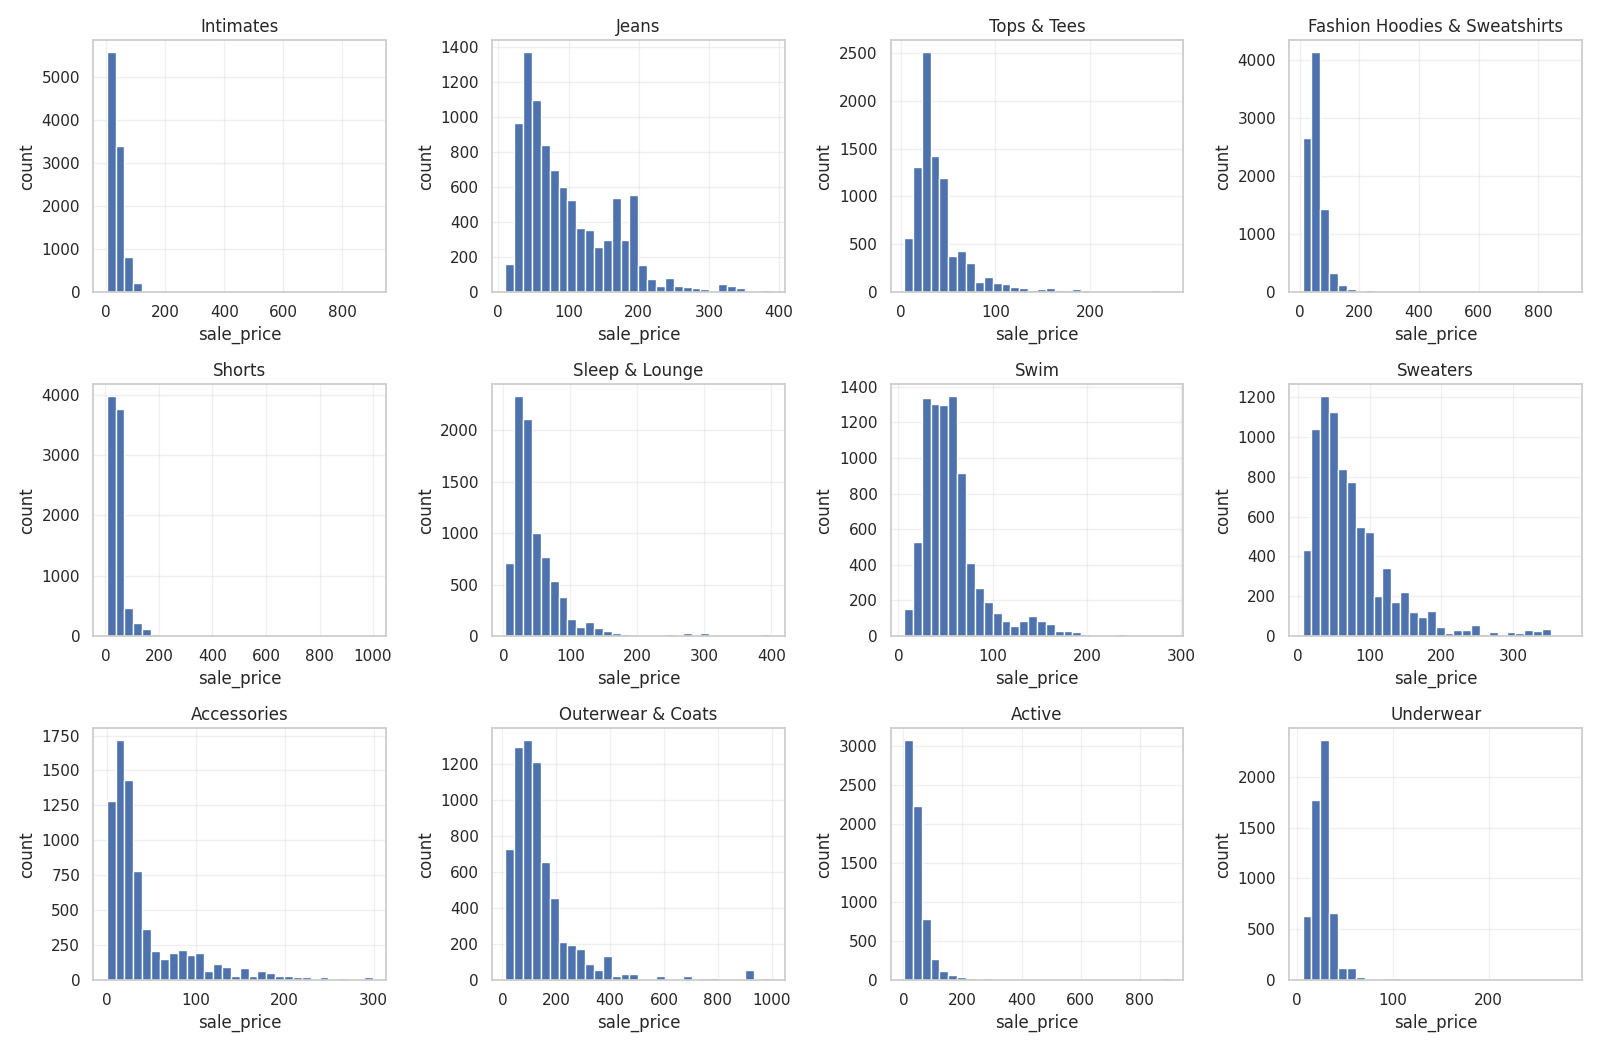

=== DF WITH NEW FEATURE ===
   user_id                       category  sale_price  price_pos_in_category  \
0    94911  Fashion Hoodies & Sweatshirts   32.990002               0.217666   
1    91961                          Pants   39.570000               0.306075   
2    91961            Suits & Sport Coats  221.979996               0.848249   
3    79993                           Plus   25.000000               0.506660   
4    74352                         Active   25.000000               0.331438   
5    91892                           Swim   12.990000               0.007816   
6    91892                      Intimates    9.000000               0.054031   
7    91892                           Plus   26.990000               0.536400   
8    91892              Blazers & Jackets  247.389999               0.924867   
9    90311                         Active   10.920000               0.037708   

   price_percentile_in_category  
0                     21.766579  
1                     3

/home/artem/.local/lib/python3.10/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


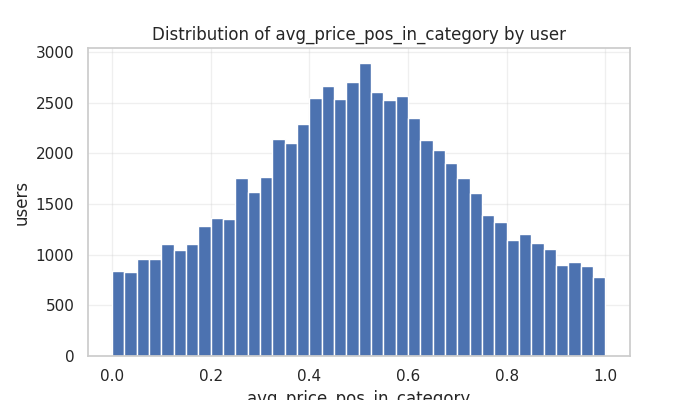

In [224]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. PREPROCESS
# =========================================================
df = df_clean.copy()

if 'returned_at' in df.columns:
    df = df[df['returned_at'].isna()]

if 'status' in df.columns:
    df = df[df['status'].isin(['Complete', 'Shipped', 'Processing'])]

required_cols = ['user_id', 'category']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# выбираем колонку цены
if 'sale_price' in df.columns:
    PRICE_COL = 'sale_price'
elif 'retail_price' in df.columns:
    PRICE_COL = 'retail_price'
else:
    raise ValueError("Нет колонки цены: ни sale_price, ни retail_price")

# убираем пропуски и невалидные цены
df = df.dropna(subset=['user_id', 'category', PRICE_COL]).copy()
df = df[df[PRICE_COL] > 0].copy()

# =========================================================
# 2. ГРАФИКИ РАСПРЕДЕЛЕНИЯ ЦЕН ВНУТРИ КАТЕГОРИЙ
# =========================================================
# берем топ-категории по числу товаров, чтобы график не был нечитаемым
top_categories = (
    df['category']
    .value_counts()
    .head(12)
    .index
    .tolist()
)

n_cols = 4
n_rows = int(np.ceil(len(top_categories) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, cat in enumerate(top_categories):
    ax = axes[i]
    vals = df.loc[df['category'] == cat, PRICE_COL].values

    ax.hist(vals, bins=30)
    ax.set_title(cat)
    ax.set_xlabel(PRICE_COL)
    ax.set_ylabel('count')
    ax.grid(alpha=0.3)

for j in range(len(top_categories), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# =========================================================
# 3. НОВАЯ ФИЧА ДЛЯ КАЖДОГО ТОВАРА:
#    ПОЗИЦИЯ ТОВАРА В РАСПРЕДЕЛЕНИИ ЦЕН СВОЕЙ КАТЕГОРИИ
# =========================================================
# Это percentile rank внутри category:
# 0.0 -> один из самых дешевых
# 1.0 -> один из самых дорогих
df['price_pos_in_category'] = (
    df.groupby('category')[PRICE_COL]
    .rank(method='average', pct=True)
)

# при желании можно сделать шкалу 0..100
df['price_percentile_in_category'] = 100 * df['price_pos_in_category']

# =========================================================
# 4. USER-LEVEL FEATURE:
#    СРЕДНЕЕ ПОЛОЖЕНИЕ ЦЕНЫ ПО ВСЕМ ТОВАРАМ ПОЛЬЗОВАТЕЛЯ
# =========================================================
user_price_profile = (
    df.groupby('user_id')
    .agg(
        avg_price_pos_in_category=('price_pos_in_category', 'mean'),
        avg_price_percentile_in_category=('price_percentile_in_category', 'mean'),
        n_items=(PRICE_COL, 'count'),
        n_orders=('order_id', 'nunique') if 'order_id' in df.columns else (PRICE_COL, 'count'),
        total_spent=(PRICE_COL, 'sum'),
        avg_item_price=(PRICE_COL, 'mean')
    )
    .reset_index()
)

# =========================================================
# 5. ДОБАВЛЯЕМ ИНФОРМАЦИЮ О ПОЛЬЗОВАТЕЛЕ
# =========================================================
user_info_cols = ['user_id', 'gender', 'is_loyal', 'country', 'age']
available_info_cols = [c for c in user_info_cols if c in df.columns]

if available_info_cols:
    user_info = df[available_info_cols].drop_duplicates(subset=['user_id'])
    user_price_profile = user_price_profile.merge(user_info, on='user_id', how='left')

# =========================================================
# 6. СОХРАНЯЕМ
# =========================================================
df.to_csv("df_with_price_position.csv", index=False)
user_price_profile.to_csv("user_price_profile.csv", index=False)

# =========================================================
# 7. БЫСТРЫЙ ПРОСМОТР
# =========================================================
print("=== DF WITH NEW FEATURE ===")
print(df[['user_id', 'category', PRICE_COL, 'price_pos_in_category', 'price_percentile_in_category']].head(10))

print("\n=== USER PROFILE ===")
print(user_price_profile.head(10))

# =========================================================
# 8. ДОПОЛНИТЕЛЬНЫЙ ГРАФИК:
#    РАСПРЕДЕЛЕНИЕ USER-LEVEL FEATURE
# =========================================================
plt.figure(figsize=(7, 4))
plt.hist(user_price_profile['avg_price_pos_in_category'].dropna(), bins=40)
plt.title('Distribution of avg_price_pos_in_category by user')
plt.xlabel('avg_price_pos_in_category')
plt.ylabel('users')
plt.grid(alpha=0.3)
plt.show()

/home/artem/.local/lib/python3.10/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


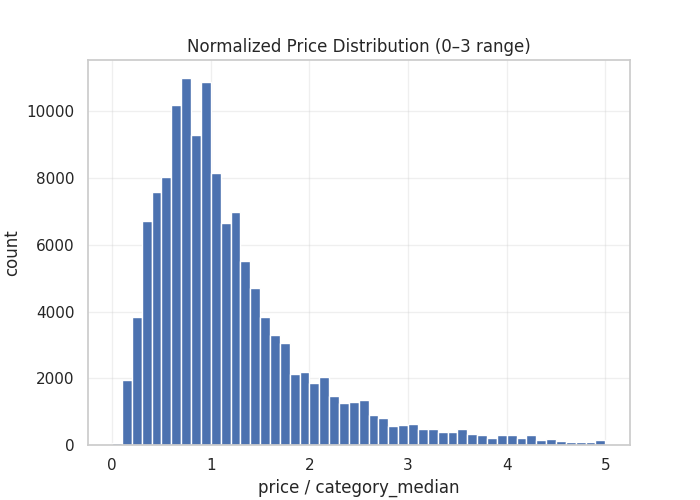

In [219]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. PREPROCESS
# =========================================================
df = df_clean.copy()

if 'returned_at' in df.columns:
    df = df[df['returned_at'].isna()]

if 'status' in df.columns:
    df = df[df['status'].isin(['Complete', 'Shipped', 'Processing'])]

# цена
if 'sale_price' in df.columns:
    PRICE_COL = 'sale_price'
elif 'retail_price' in df.columns:
    PRICE_COL = 'retail_price'
else:
    raise ValueError("Нет колонки цены")

# чистка
df = df.dropna(subset=[PRICE_COL, 'category'])
df = df[df[PRICE_COL] > 0]

# =========================================================
# 2. НОРМИРОВКА (лучше медиана)
# =========================================================
category_median = df.groupby('category')[PRICE_COL].median()
df['price_norm'] = df[PRICE_COL] / df['category'].map(category_median)

# =========================================================
# 3. ФИЛЬТР 0–3
# =========================================================
df_plot = df[(df['price_norm'] >= 0) & (df['price_norm'] <= 5)]

# =========================================================
# 4. HISTOGRAM
# =========================================================
plt.figure(figsize=(7, 5))

plt.hist(df_plot['price_norm'], bins=50)

plt.xlabel('price / category_median')
plt.ylabel('count')
plt.title('Normalized Price Distribution (0–3 range)')
plt.grid(alpha=0.3)

plt.show()

/tmp/ipykernel_7411/3654865177.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['gender', 'price_class'])['user_id']
/tmp/ipykernel_7411/3654865177.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['gender', 'price_class', 'category'])['user_id']
/tmp/ipykernel_7411/3654865177.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['gender','price_class'])
/home/artem/.local/lib/python3.

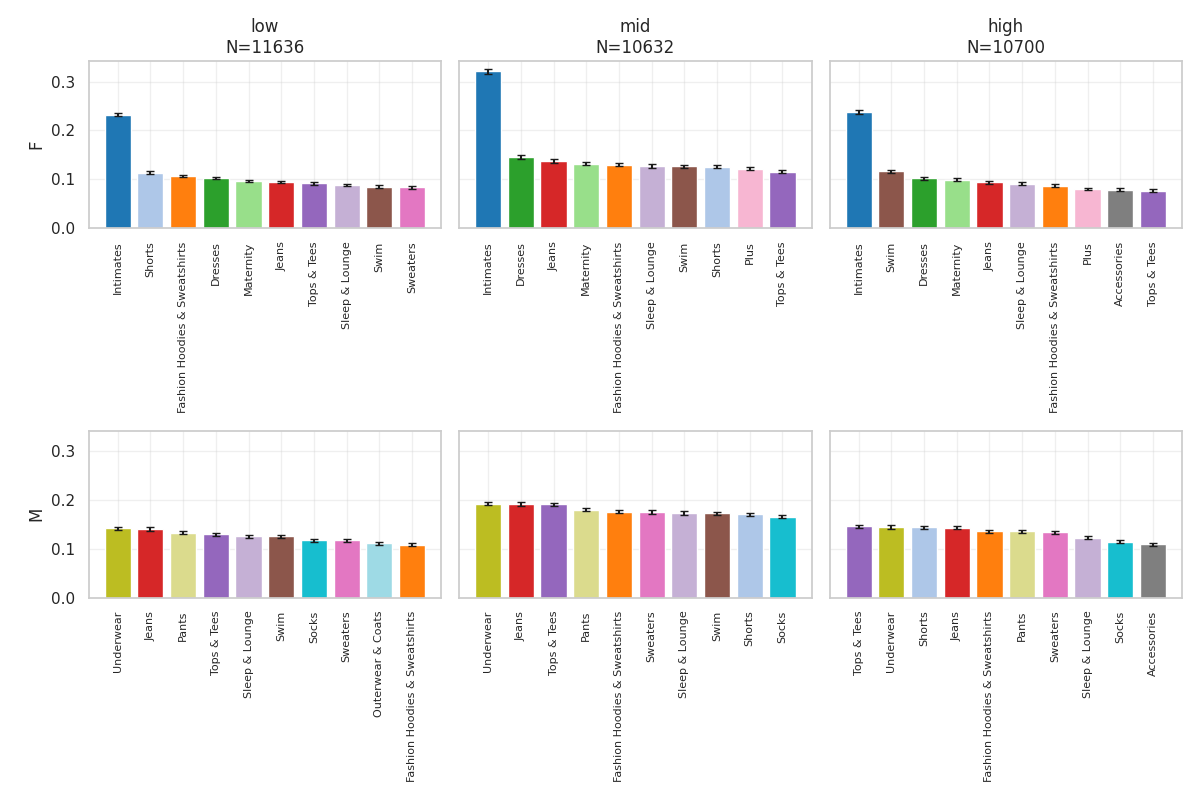

In [220]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. LOAD
# =========================================================
df = pd.read_csv("df_with_price_position.csv")
user_profile = pd.read_csv("user_price_profile.csv")

# =========================================================
# 2. СЕГМЕНТАЦИЯ (равные группы)
# =========================================================
user_profile = user_profile.dropna(subset=['avg_price_pos_in_category'])

user_profile['price_class'] = pd.qcut(
    user_profile['avg_price_pos_in_category'],
    q=3,
    labels=['low', 'mid', 'high']
)

# =========================================================
# 3. MERGE В DF
# =========================================================
df = df.merge(
    user_profile[['user_id', 'price_class']],
    on='user_id',
    how='inner'
)

# =========================================================
# 4. CATEGORY DISTRIBUTION
# =========================================================
# считаем долю пользователей (а не строк!)
user_cat = (
    df.groupby(['user_id', 'category'])
    .size()
    .reset_index(name='cnt')
)

user_cat['bought'] = 1

user_info = df[['user_id', 'gender', 'price_class']].drop_duplicates()
user_cat = user_cat.merge(user_info, on='user_id')

# =========================================================
# 5. SEGMENT SIZE
# =========================================================
segment_size = (
    user_info
    .groupby(['gender', 'price_class'])['user_id']
    .nunique()
    .reset_index(name='n_users')
)

# =========================================================
# 6. USERS WHO BOUGHT CATEGORY
# =========================================================
segment_cat = (
    user_cat
    .groupby(['gender', 'price_class', 'category'])['user_id']
    .nunique()
    .reset_index(name='n_buyers')
)

segment_cat = segment_cat.merge(segment_size, on=['gender', 'price_class'])
segment_cat['prob'] = segment_cat['n_buyers'] / segment_cat['n_users']

# =========================================================
# 7. TOP-10 КАТЕГОРИЙ
# =========================================================
top10 = (
    segment_cat
    .sort_values(['gender','price_class','prob'], ascending=[True, True, False])
    .groupby(['gender','price_class'])
    .head(10)
    .reset_index(drop=True)
)

# =========================================================
# 8. PLOT
# =========================================================
genders = sorted(top10['gender'].unique())
classes = ['low', 'mid', 'high']

fig, axes = plt.subplots(len(genders), len(classes),
                         figsize=(4*len(classes), 4*len(genders)),
                         sharey=True)

# цвет категорий
all_categories = top10['category'].astype(str).unique()
color_map = {cat: i for i, cat in enumerate(all_categories)}
cmap = plt.cm.get_cmap('tab20', len(all_categories))

for i, gender in enumerate(genders):
    for j, cls in enumerate(classes):

        ax = axes[i, j]

        df_plot = top10[
            (top10['gender'] == gender) &
            (top10['price_class'] == cls)
        ]

        if df_plot.empty:
            ax.set_title(f"{cls}\n(empty)")
            continue

        cats = df_plot['category'].astype(str).values
        probs = df_plot['prob'].values
        n_users = int(df_plot['n_users'].iloc[0])

        errors = np.sqrt(probs * (1 - probs) / n_users)

        x = np.arange(len(cats))
        colors = [cmap(color_map[c]) for c in cats]

        ax.bar(x, probs, yerr=errors, capsize=3, color=colors)

        ax.set_xticks(x)
        ax.set_xticklabels(cats, rotation=90, fontsize=8)

        if i == 0:
            ax.set_title(f"{cls}\nN={n_users}")

        if j == 0:
            ax.set_ylabel(gender)

        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [221]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# =========================================================
# 1. CONTINGENCY TABLE
# =========================================================
# user-level (важно!)
user_cat = (
    df.groupby(['user_id', 'category'])
    .size()
    .reset_index(name='cnt')
)

user_cat['bought'] = 1

user_info = df[['user_id', 'price_class']].drop_duplicates()
user_cat = user_cat.merge(user_info, on='user_id')

# =========================================================
# 2. TABLE
# =========================================================
contingency = pd.crosstab(
    user_cat['price_class'],
    user_cat['category']
)

# =========================================================
# 3. CHI-SQUARE TEST
# =========================================================
chi2, p_value, dof, expected = chi2_contingency(contingency)

print("Chi2:", chi2)
print("p-value:", p_value)
print("dof:", dof)

# =========================================================
# 4. CRAMER'S V
# =========================================================
n = contingency.values.sum()
r, k = contingency.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("Cramer's V:", cramers_v)

# =========================================================
# 5. INTERPRETATION
# =========================================================
if p_value < 0.05:
    print("\n❌ Есть зависимость категорий от price_class")
else:
    print("\n✅ Зависимости не обнаружено")

Chi2: 123.1206382262685
p-value: 4.197617273669997e-08
dof: 50
Cramer's V: 0.02198468597129751

❌ Есть зависимость категорий от price_class


In [222]:
df_sorted = df.sort_values(['user_id', 'created_at'])

df_sorted['prev_category'] = df_sorted.groupby('user_id')['category'].shift(1)

pd.crosstab(df_sorted['prev_category'], df_sorted['category'], normalize='index')

category,Accessories,Active,Blazers & Jackets,Clothing Sets,Dresses,Fashion Hoodies & Sweatshirts,Intimates,Jeans,Jumpsuits & Rompers,Leggings,...,Skirts,Sleep & Lounge,Socks,Socks & Hosiery,Suits,Suits & Sport Coats,Sweaters,Swim,Tops & Tees,Underwear
prev_category,,,,,,,,,,,,,,,,,,,,,
Accessories,0.051607,0.050633,0.016310,0.000974,0.022152,0.064508,0.062804,0.071568,0.003651,0.014606,...,0.009494,0.065969,0.035784,0.014362,0.006329,0.029942,0.059153,0.066212,0.072785,0.050633
Active,0.049562,0.049562,0.013417,0.000821,0.028478,0.072563,0.055312,0.075575,0.005750,0.013965,...,0.010953,0.069003,0.028478,0.014786,0.007667,0.039430,0.066813,0.069825,0.060789,0.038061
Blazers & Jackets,0.042907,0.047285,0.030648,0.003503,0.068301,0.059545,0.137478,0.064799,0.006130,0.027145,...,0.028897,0.054291,0.000000,0.028897,0.016637,0.000000,0.049037,0.037653,0.049037,0.000000
Clothing Sets,0.089552,0.029851,0.014925,0.000000,0.104478,0.029851,0.164179,0.059701,0.014925,0.000000,...,0.029851,0.029851,0.000000,0.014925,0.029851,0.000000,0.029851,0.074627,0.059701,0.000000
Dresses,0.033916,0.042395,0.038686,0.002120,0.068362,0.056704,0.127716,0.066773,0.006889,0.030207,...,0.028087,0.055114,0.000000,0.029147,0.019078,0.000000,0.046105,0.051404,0.048225,0.000000
Fashion Hoodies & Sweatshirts,0.045938,0.053179,0.018783,0.002263,0.029645,0.075356,0.052953,0.087124,0.004300,0.011994,...,0.010636,0.062684,0.023535,0.011994,0.005205,0.041186,0.078072,0.061552,0.057479,0.028061
Intimates,0.039936,0.039579,0.038866,0.003387,0.062043,0.061687,0.140310,0.060082,0.009627,0.031378,...,0.024603,0.052416,0.000000,0.031022,0.011945,0.000000,0.047780,0.067035,0.046532,0.000000
Jeans,0.049611,0.041342,0.018239,0.001459,0.025535,0.067364,0.045233,0.092169,0.003891,0.012160,...,0.008025,0.063230,0.028940,0.011673,0.004377,0.042315,0.073687,0.067850,0.061770,0.035749
Jumpsuits & Rompers,0.036415,0.036415,0.022409,0.000000,0.058824,0.047619,0.156863,0.058824,0.008403,0.039216,...,0.016807,0.053221,0.000000,0.042017,0.019608,0.000000,0.030812,0.067227,0.028011,0.000000


In [223]:
import pandas as pd
import numpy as np
from itertools import combinations
from collections import defaultdict

# =========================================================
# 1. BASKETS
# =========================================================
baskets = df.groupby('order_id')['category'].apply(set)

# =========================================================
# 2. COUNTS
# =========================================================
item_count = defaultdict(int)
pair_count = defaultdict(int)

n_orders = len(baskets)

for basket in baskets:
    for item in basket:
        item_count[item] += 1

    for a, b in combinations(basket, 2):
        pair = tuple(sorted((a, b)))
        pair_count[pair] += 1

# =========================================================
# 3. LIFT
# =========================================================
lift = {}

for (a, b), pab_count in pair_count.items():

    p_ab = pab_count / n_orders
    p_a = item_count[a] / n_orders
    p_b = item_count[b] / n_orders

    lift[(a, b)] = p_ab / (p_a * p_b)

# =========================================================
# 4. RESULT
# =========================================================
lift_df = pd.DataFrame([
    {'item_A': a, 'item_B': b, 'lift': val}
    for (a, b), val in lift.items()
])

lift_df = lift_df.sort_values('lift', ascending=False)

print(lift_df.head(20))

                  item_A           item_B      lift
241        Clothing Sets   Pants & Capris  1.909791
261  Jumpsuits & Rompers            Suits  1.774631
196       Pants & Capris            Suits  1.699738
260        Clothing Sets        Maternity  1.584140
256        Clothing Sets         Leggings  1.528059
238             Leggings            Suits  1.505706
269        Clothing Sets          Dresses  1.473266
258        Clothing Sets        Intimates  1.471129
179    Blazers & Jackets        Maternity  1.450158
226             Leggings        Maternity  1.445682
171  Jumpsuits & Rompers  Socks & Hosiery  1.439726
197    Blazers & Jackets   Pants & Capris  1.409030
140                 Plus           Skirts  1.400839
191            Maternity             Plus  1.372019
169              Dresses            Suits  1.370827
85               Dresses           Skirts  1.348661
266        Clothing Sets            Suits  1.345090
176              Dresses             Plus  1.343148
73     Blaze

array(['Shipped', 'Complete', 'Processing'], dtype=object)

In [228]:
prep = SimplePreprocessor()

df_clean = prep.transform(data)

Initial rows: 545778
After column selection: 545778
After drop_duplicates: 181916
After dropna: 181732
After status filter: 136054


/home/artem/.local/lib/python3.10/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


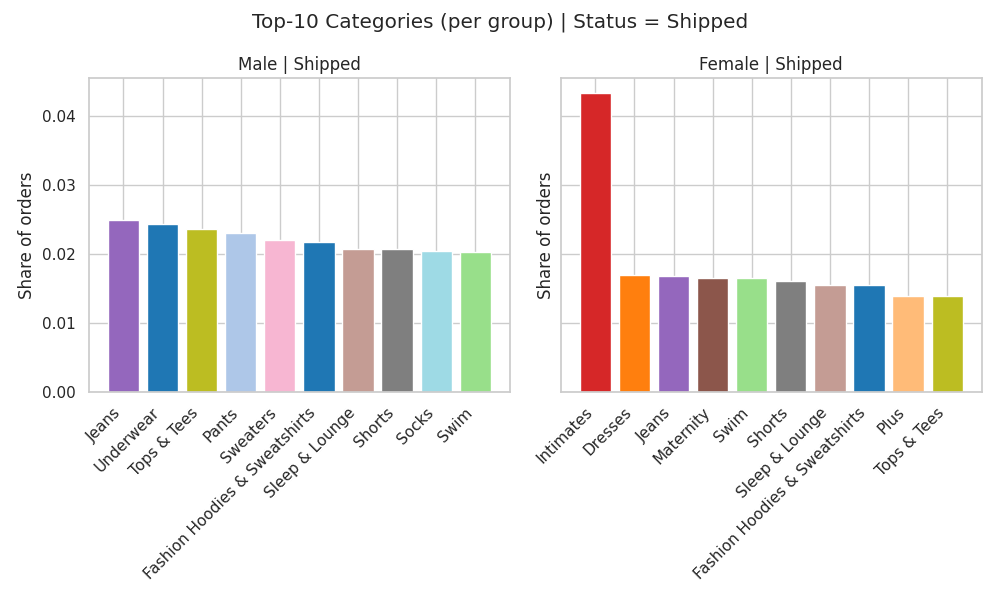

/home/artem/.local/lib/python3.10/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


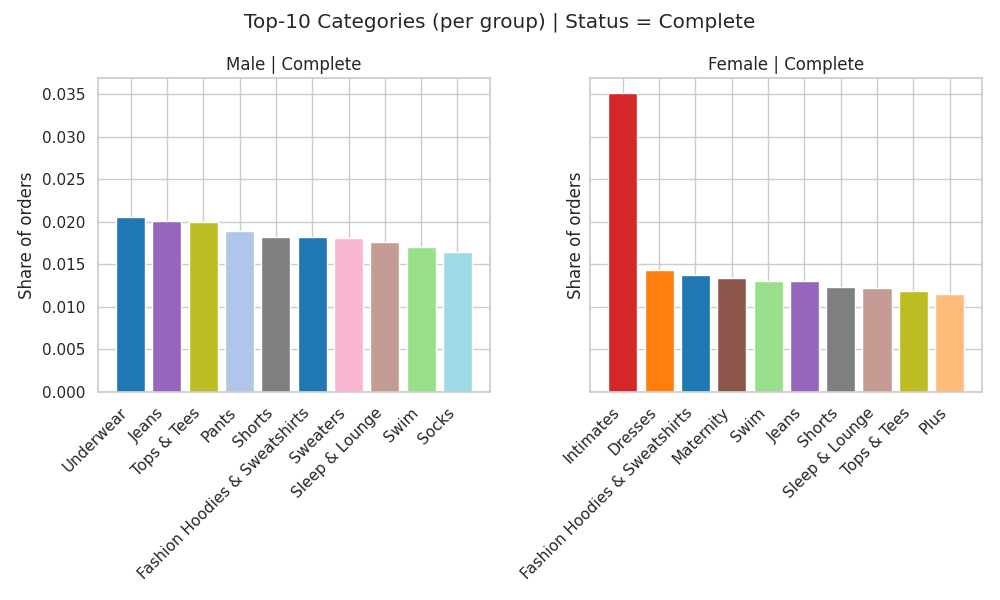

/home/artem/.local/lib/python3.10/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


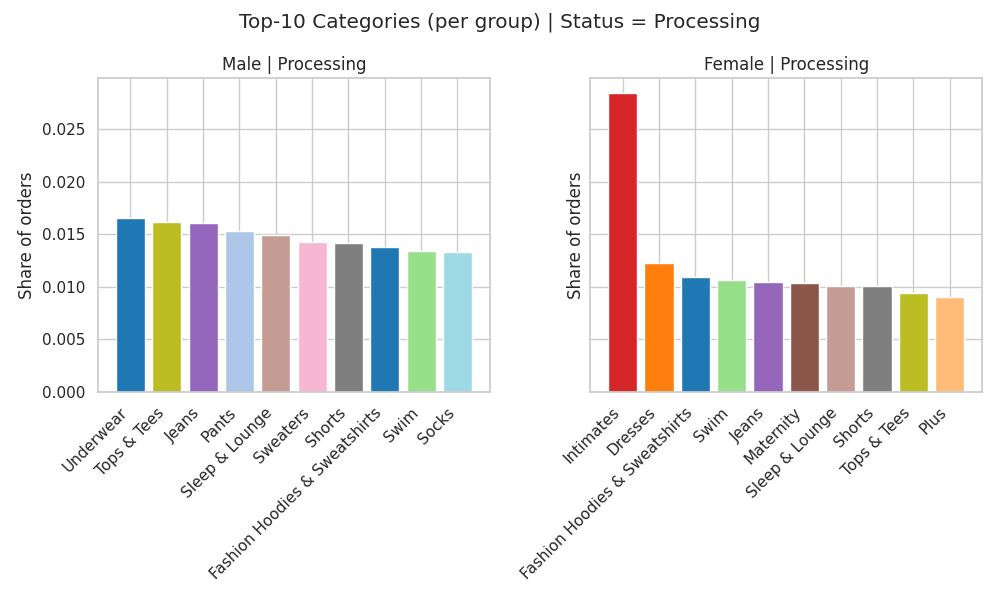

In [229]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = df_clean.copy()

# =========================
# 1. FILTER VALID ORDERS
# =========================
invalid_status = ['Returned', 'Cancelled', 'Canceled']
df_valid = df[~df['status'].isin(invalid_status)].copy()

total_orders = df_valid['order_id'].nunique()

# =========================
# 2. СОЗДАЕМ ГЛОБАЛЬНУЮ ЦВЕТОВУЮ СХЕМУ
# =========================
all_categories = df_valid['category'].unique()

cmap = plt.get_cmap('tab20')
color_map = {cat: cmap(i % 20) for i, cat in enumerate(all_categories)}

# =========================
# 3. PLOT
# =========================
statuses = df['status'].dropna().unique()

for status in statuses:
    df_status = df[df['status'] == status]

    fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

    for i, gender in enumerate(['M', 'F']):
        df_group = df_status[df_status['gender'] == gender]

        # свой топ-10
        counts = (
            df_group['category']
            .value_counts()
            .head(10)
        )

        counts_norm = counts / total_orders

        x = np.arange(len(counts))

        colors = [color_map[cat] for cat in counts.index]

        axes[i].bar(x, counts_norm.values, color=colors)

        axes[i].set_xticks(x)
        axes[i].set_xticklabels(counts.index, rotation=45, ha='right')
        axes[i].set_title(f"{'Male' if gender == 'M' else 'Female'} | {status}")
        axes[i].set_ylabel("Share of orders")

    plt.suptitle(f"Top-10 Categories (per group) | Status = {status}")
    plt.tight_layout()
    plt.show()